# RCWA convergence test

In [1]:
""" Helper functions """
import math
import torch
from typing import Optional, Sequence, Tuple

from dispertorch import ConstantEps
from metashapes import Shape
from metashapes.shape import Rectangle, Ellipse

from metarcwa import IsotropicMedium, Source, Stack, Lattice, Model, Layer
from metarcwa.model.adapters import from_dispertorch, from_metashapes
from metarcwa import Config, Solver, Factorization
from metarcwa import Observables
import matplotlib.pyplot as plt


def build_model(shape: Shape,
                thickness: torch.Tensor,
                eps_solid: ConstantEps,
                eps_void: ConstantEps,
                eps_inc: ConstantEps,
                eps_trans: ConstantEps,
                period: torch.Tensor,
                wl: torch.Tensor,
                theta: torch.Tensor,
                phi: torch.Tensor) -> Model:
    """Build a two-medium (no finite layers) single-interface Model.

    Parameters
    ----------
    eps1, eps2 : ConstantEps
        Dispersion models for the incidence (1) and transmission (2)
        half-spaces, wrapped into ``IsotropicMedium`` via ``from_dispertorch``.
    period : torch.Tensor
        Lattice period (px = py), used only to define a (physically
        irrelevant, since the interface is unpatterned) reciprocal lattice
        for the harmonic expansion.
    wl : torch.Tensor
        Free-space wavelength(s).
    theta : torch.Tensor
        Polar incidence angle(s) in radians, measured from the interface
        normal.
    phi : torch.Tensor
        Azimuthal incidence angle(s) in radians.

    Returns
    -------
    Model
        Ready to pass to ``Solver``.
    """
    medium_inc = IsotropicMedium(from_dispertorch(eps_inc))
    medium_trans = IsotropicMedium(from_dispertorch(eps_trans))
    medium_solid = IsotropicMedium(from_dispertorch(eps_solid))
    medium_void = IsotropicMedium(from_dispertorch(eps_void))

    lattice = Lattice.rectangular(px=period, py=period)
    
    layer = Layer(medium_solid, thickness, medium_void, from_metashapes(shape))

    stack = Stack(medium_inc, [layer], medium_trans, lattice)
    src = Source(wl, theta, phi)

    model = Model(stack, src)

    return model


def build_config(dtype: torch.dtype, device: torch.device, 
                 m: int, n:int, nx: int, ny:int, truncation: str, fact_method: str | None,
                 fact_beta: float, fact_gamma: float) -> Config:
    
    if fact_method is not None:
        factorization = Factorization(method=fact_method, beta=fact_beta, gamma=fact_gamma)
    else:
        factorization = None
    return Config(dtype, device, m=m, n=n, nx=nx, ny=ny, truncation=truncation, factorization=factorization)


def compute_rt(model: Model, config: Config) -> Tuple[torch.Tensor,
                                                    torch.Tensor,
                                                    torch.Tensor,
                                                    torch.Tensor]:
    """Solve the interface and return specular-order power R/T for both polarizations.

    Reflectance is simply ``|r|**2`` (both half-spaces carry the same
    incident/reflected medium, so no flux normalization is needed).
    Transmittance additionally needs the ratio of Poynting flux (``kz``,
    i.e. ``n*cos(theta)``) crossing the interface in each medium:

        T = Re(n2*cos(theta_t)) / Re(n1*cos(theta_i)) * |t|**2

    with ``cos(theta_t)`` from Snell's law (``sin(theta_t) = (n1/n2)*sin(theta_i)``).
    The ``+0j`` under the square root keeps this valid past the critical
    angle, where ``cos(theta_t)`` becomes purely imaginary (evanescent
    transmitted field, T=0 exactly since ``Re(cos(theta_t))=0`` there).

    Parameters
    ----------
    model : Model
        Built by :func:`build_model`.
    config : Config
        Built by :func:`build_config`.

    Returns
    -------
    Rs, Rp, Ts, Tp : torch.Tensor
        Power reflectance/transmittance for s- and p-polarized incidence,
        shape ``[N_wl, N_theta, N_phi]`` (matching ``Source``'s sweep axes).
    """
    solver = Solver(model, config)
    solution = solver.run()
    obs = Observables(solution)

    # Compute reflection
    rs, _ = obs.reflection(pol='s')
    _, rp = obs.reflection(pol='p')

    Rs = torch.abs(rs.cpu())**2
    Rp = torch.abs(rp.cpu())**2

    # Compute transmission
    ts, _ = obs.transmission(pol='s')
    _, tp = obs.transmission(pol='p')

    n1 = (model.stack.incidence.eps_fn(model.source.wavelength)**0.5).cpu().reshape(-1, 1, 1)
    n2 = (model.stack.transmission.eps_fn(model.source.wavelength)**0.5).cpu().reshape(-1, 1, 1)

    theta = model.source.theta.cpu().reshape(1, -1, 1)
    cos_i = torch.cos(theta)
    sin_t = (n1 / n2) * torch.sin(theta)
    cos_t = torch.sqrt(1 - sin_t**2 + 0j)

    coeff = torch.real(n2 * cos_t) / torch.real(n1 * cos_i)

    Ts = coeff*torch.abs(ts.cpu())**2
    Tp = coeff*torch.abs(tp.cpu())**2

    return Rs, Rp, Ts, Tp

from dataclasses import replace

@torch.no_grad()
def convergence_test(model: Model, config: Config, m_max: int, N: int = 512):
    assert N >= 4 * m_max + 1, f"grid {N} too coarse for m_max={m_max}"

    orders = list(range(1, m_max + 1))
    results = []

    for m in orders:
        cfg = replace(config, m=m, n=m, nx=N, ny=N)
        Rs, Rp, Ts, Tp = compute_rt(model, cfg)
        results.append(torch.stack([Rs, Rp, Ts, Tp]))

    ref = results[-1]
    errs = torch.stack([torch.mean((r - ref) ** 2) for r in results[:-1]])

    return orders[:-1], errs
    


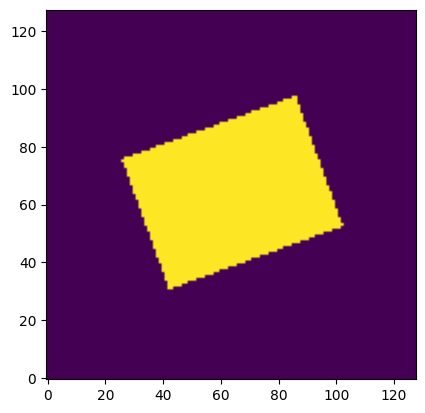

In [2]:
# Define config
dtype = torch.float32
device = "cuda:0"
N = 256
m = 10 # Num_harmonics_x = 2*m + 1
n = 10 # Num_harmonics_y = 2*n + 1
truncation = "circular" # "circular", "rectangular"
fact_method = None # "Normal", "Pol", "Jones", "Jones_direct"
fact_beta = 0.05
fact_gamma = 0.05
nx = N
ny = N

# Define model parameters
eps_inc = ConstantEps(1.0)
eps_trans = ConstantEps(1.46**2)
eps_void = ConstantEps(1.0)
eps_solid = ConstantEps(2.1**2, eps_im=0.0)
period = 400.0
thickness = 200.0

# Define shape
xc, yc = period/2, period/2
w, h = 200.0, 150.0
angle = 20.0
corner_radius = 0.0
shape = Rectangle((xc, yc), (w, h), angle=angle, corner_radius=corner_radius)

wl = torch.linspace(300, 800, 1)
theta = torch.tensor([0.0])*torch.pi/180.0
phi = torch.tensor([30.0])*torch.pi/180.0

# Prepare model
model = build_model(shape, thickness, eps_solid, eps_void, eps_inc, eps_trans, period, wl, theta, phi)

# Show unit cell
plt.figure()
plt.imshow(model.spec(nx=128, ny=128).layers[0].pattern, origin="lower")
plt.show()

config = build_config(dtype, device, m, n, nx, ny, truncation, fact_method, fact_beta, fact_gamma)

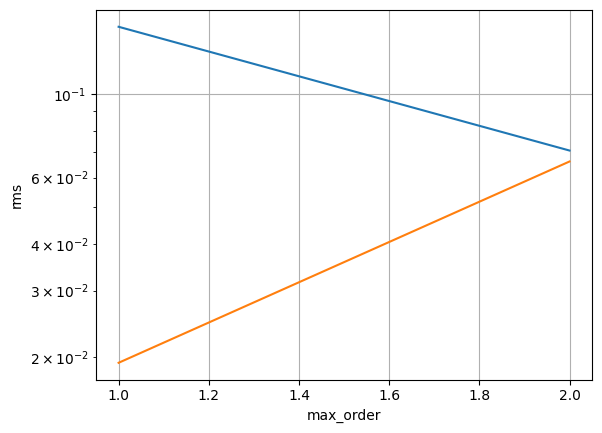

In [6]:
# Comparison between 32 and 64 bits convergence

m_max=3

orders, errs = convergence_test(model, config, m_max=m_max)

config = build_config(dtype, device, m, n, nx, ny, truncation, "Jones_direct", fact_beta, fact_gamma)
orders, errs_normal = convergence_test(model, config, m_max=m_max)
config = build_config(dtype, device, m, n, nx, ny, truncation, None, fact_beta, fact_gamma)

plt.plot(orders, torch.sqrt(errs))
plt.plot(orders, torch.sqrt(errs_normal))
plt.yscale('log', base=10)
plt.xlabel('max_order')
plt.ylabel('rms')
plt.grid()